In [17]:
# Importing modules
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score


In [18]:
# loading and preprocessing data
df = pd.read_csv("student_data.csv")

df.drop_duplicates(inplace=True)

cols_to_drop = ['school', 'address', 'famsize', 'reason']
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

null_counts = df.isnull().sum()

for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col] = df[col].fillna(df[col].median())

for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].fillna(df[col].mode()[0])

print(df.shape)
df.head()


(395, 29)


,sex,age,Pstatus,Medu,Fedu,Mjob,Fjob,guardian,traveltime,studytime,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,F,18,A,4.0,4,at_home,teacher,mother,2,2,...,4,3,4,1,1,3,6,5,6,6
1,F,17,T,1.0,1,at_home,other,father,1,2,...,5,3,3,1,1,3,4,5,5,6
2,F,15,T,1.0,1,at_home,other,mother,1,2,...,4,3,2,2,3,3,10,7,8,10
3,F,15,T,4.0,2,health,services,mother,1,3,...,3,2,2,1,1,5,2,15,14,15
4,F,16,T,3.0,3,other,other,father,1,2,...,4,3,2,1,2,5,4,6,10,10


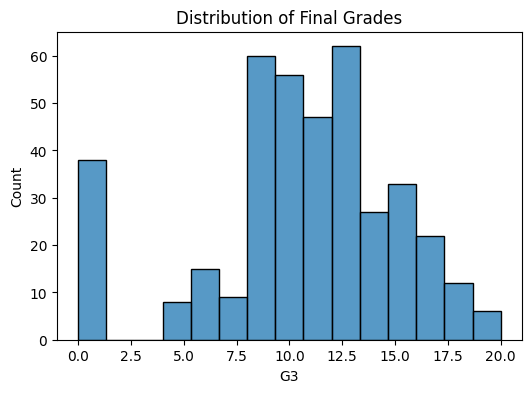

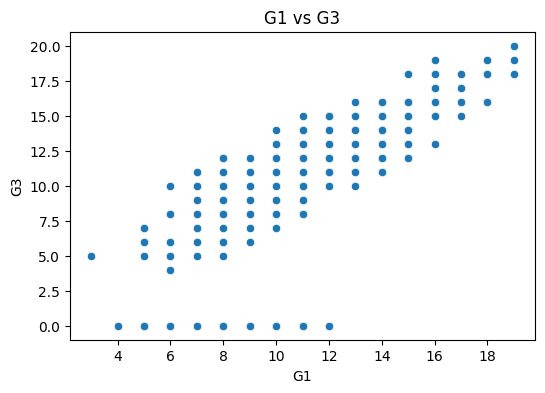

In [19]:
# Exploratory Data Analysis
plt.figure(figsize=(6,4))
sns.histplot(df['G3'], bins=15)
plt.title("Distribution of Final Grades")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x=df['G1'], y=df['G3'])
plt.title("G1 vs G3")
plt.show()


In [20]:
# Feature selection
features = ['sex', 'age', 'studytime', 'failures', 'absences', 'G1', 'G2']
df_model = df[features + ['G3']].copy()

df_model.head()


,sex,age,studytime,failures,absences,G1,G2,G3
0,F,18,2,0,6,5,6,6
1,F,17,2,0,4,5,5,6
2,F,15,2,3,10,7,8,10
3,F,15,3,0,2,15,14,15
4,F,16,2,0,4,6,10,10


In [21]:
# Feature Encoding
df_model['sex'] = df_model['sex'].map({'F': 0, 'M': 1})


In [22]:
# Train-test split
X = df_model.drop('G3', axis=1)
y = df_model['G3']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [23]:
# Model creation and training
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)


,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
# Evaluation
y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))


MAE: 1.0312732067510548
R2 Score: 0.8530839444965934


In [25]:
# Sample Prediction
sample = [[1, 17, 2, 0, 5, 10, 12]]

prediction = model.predict(sample)

print("Predicted Final Grade:", round(prediction[0], 2))


Predicted Final Grade: 11.97


c:\Users\windows@priyanshu18\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


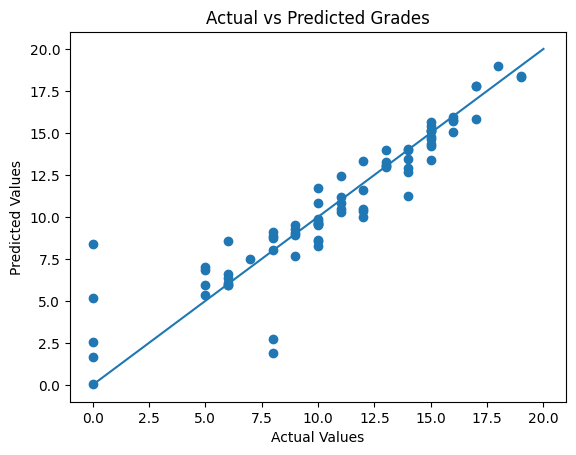

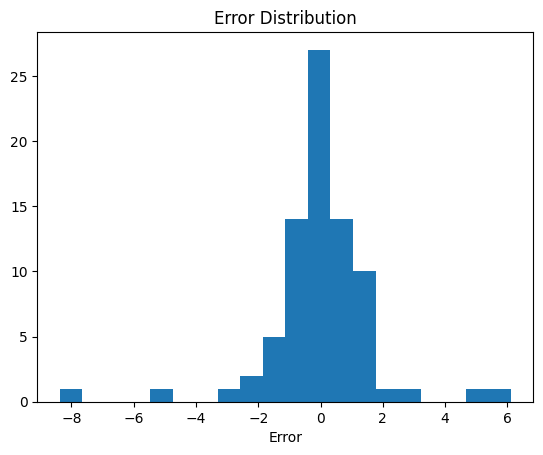

In [27]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Grades")

# perfect prediction line
plt.plot([0,20], [0,20])

plt.show()

errors = y_test - y_pred

plt.hist(errors, bins=20)
plt.title("Error Distribution")
plt.xlabel("Error")
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
